In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
# import seaborn as sns
table = pd.read_csv('/Users/jerometubiana/GitHub/LocAlign/plots/per_sample_results_9-87099.csv')

In [2]:
import matplotlib.pyplot as plt
sns.scatterplot(data=table,x='ligand_rmsd',y='embedding_similarity',
                hue='corr_rmsd')
plt.xlim([0,15])

NameError: name 'sns' is not defined

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import HistGradientBoostingRegressor

table['normalized_embedding_similarity'] = table['embedding_similarity'] / (table['entropy'] * np.log(400) )
table['perplexity'] = table['entropy'].map(lambda x: np.exp (x * np.log(400)) )
 
# features = ['embedding_similarity','corr_rmsd','radius_of_gyration','entropy']

# features = ['normalized_embedding_similarity','corr_rmsd','radius_of_gyration','perplexity']
features = ['normalized_embedding_similarity','corr_rmsd','perplexity']

target = 'ligand_rmsd'

X = table[features]
y = table[target].map(lambda x: np.clip(x,0,10))

thresholds = np.array([0.5, 1.,2.,4.])
# y = table[target].map( lambda x: (x>=thresholds).sum() )

z = table['cath_degree']
index = table['Unnamed: 0']

X_train,X_test,y_train,y_test,z_train,z_test,index_train,index_test = train_test_split(X,y,z,index)

regressor = HistGradientBoostingRegressor(loss='absolute_error',
                                          # monotonic_cst=np.array([-1,1,1,-1])
                                          monotonic_cst=np.array([-1,1,1,-1])
                                        #   monotonic_cst={
                                        #       'normalized_embedding_similarity':-1,
                                        #       'corr_rmsd':1,
                                        #       'radius_of_gyration':1,
                                        #       'perplexity':-1
                                        #   }
                                          )


regressor.fit(X_train,y_train)

predictions = regressor.predict(X_test)

fig, ax = plt.subplots(figsize=(12,12))
plt.scatter(y_test,predictions,c=z_test )
# sns.swarmplot(x=y_test,y=predictions,hue=z_test); 

print(np.corrcoef(y_test,predictions)[0,1])

plt.show()


order_predictions = np.argsort(predictions)
top_predictions = index_test.iloc[order_predictions]
top_table = table.iloc[top_predictions]
top_table_not_cath_4 = top_table[(top_table['cath_degree']<4) & (top_table['perplexity'] < 80)]
top_table_not_cath_4[:20]

# print( table.iloc[index_test[ (predictions<=1.75) & (z_test<4)]])



ValueError: monotonic_cst has shape (4,) but the input data X has 3 features.

In [4]:
import pickle
pickle.dump(regressor, open('../checkpoints/baseline-embed01-ligand5-corr1-recycle4-radius05-sched-corr2/calibration_model_bis.pkl','wb'))

In [108]:
pwd

'/Users/jerometubiana/GitHub/LocAlign/notebooks'

In [101]:

order_predictions = np.argsort(predictions)
top_predictions = index_test.iloc[order_predictions]
top_table = table.iloc[top_predictions]
top_table_bad = top_table[top_table['ligand_rmsd']>5]
top_table_bad



,Unnamed: 0,Ligand_ID,ref_protein,ref_chain,mov_protein,mov_chain,cath_degree,ligand_rmsd,embedding_similarity,corr_rmsd,entropy,atom_type_fraction,radius_of_gyration,normalized_embedding_similarity,perplexity,Success
1844,1844,AP5,3be4,A,4mkh,A,4,15.548721,5.113012,0.472758,0.893006,0.993233,0.709633,0.955629,210.695271,False
1751,1751,AP5,3be4,A,4qbg,B,4,15.565082,5.121865,0.433693,0.896760,0.997117,0.707311,0.953276,215.488481,False
1949,1949,AP5,3be4,A,3fb4,A,4,15.638567,5.003018,0.522318,0.869703,0.996136,0.729207,0.960126,183.239155,False
1910,1910,DUP,3tp1,A,6hde,B,4,25.824781,4.584461,0.618495,0.882969,0.991987,0.785739,0.866583,198.397924,False
2282,2282,ACO,1hm8,A,4isx,A,4,23.449207,4.360785,0.643809,0.871060,0.963155,0.777428,0.835571,184.735522,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
309,309,CA,1w3w,A,3i57,A,0,48.861088,2.307277,1.629864,0.682569,0.928573,1.132337,0.564183,59.715142,False
329,329,CA,4esv,C,4yl9,D,0,32.884930,1.930616,1.508805,0.704135,0.970590,1.150414,0.457622,67.951983,False
962,962,MG,3bzn,A,7ef7,A,1,8.534627,2.055904,1.605222,0.714290,0.604971,1.139145,0.480391,72.214757,False
386,386,HEM,2oyy,A,3dhr,A,0,18.230927,1.702923,1.853144,0.684633,0.920905,1.146312,0.415149,60.458205,False


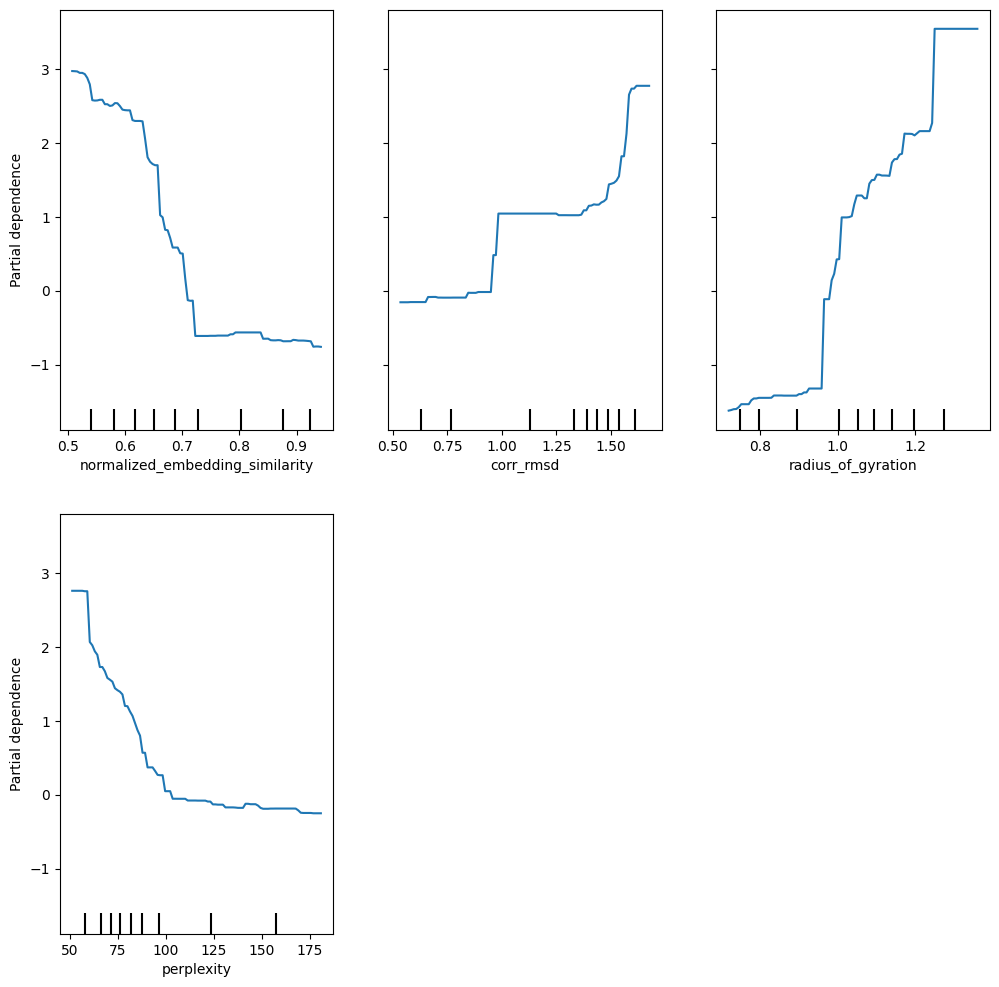

In [6]:
from sklearn.inspection import PartialDependenceDisplay
fig, ax  = plt.subplots(figsize=(12,12))
PartialDependenceDisplay.from_estimator(regressor,X_train,features=features,ax=ax)
plt.show()
# fig, ax  = plt.subplots(figsize=(12,12))
# PartialDependenceDisplay.from_estimator(regressor2,X_train,features=features,ax=ax)
# plt.tight_layout()

In [67]:
table.columns

Index(['Unnamed: 0', 'Ligand_ID', 'ref_protein', 'ref_chain', 'mov_protein',
       'mov_chain', 'cath_degree', 'ligand_rmsd', 'embedding_similarity',
       'corr_rmsd', 'entropy', 'atom_type_fraction', 'radius_of_gyration',
       'normalized_embedding_similarity', 'perplexity'],
      dtype='object')

cath_degree
0    0.167355
1    0.195775
2    0.208431
3    0.135135
4    0.815835
Name: Success, dtype: float64


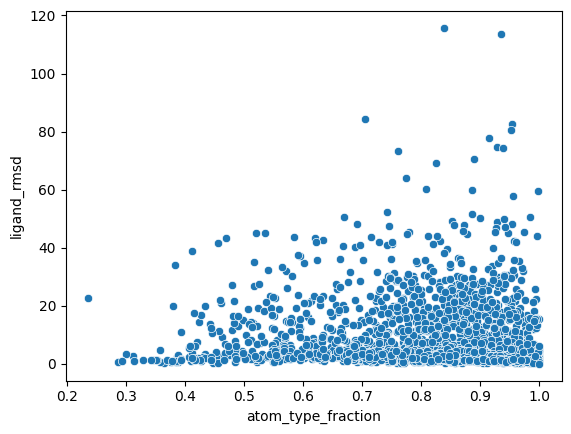

In [76]:
sns.scatterplot(table,x='atom_type_fraction',y='ligand_rmsd')

table['Success'] = (table['ligand_rmsd'] <= 3.0) & \
            (table['corr_rmsd'] <= 1.5) & \
                (table['atom_type_fraction'] >= 0.6)
                
print(table.groupby('cath_degree')['Success'].mean())
                    

In [104]:
list_entries = []

with open('/Users/jerometubiana/Downloads/protein_nr.fasta','r') as f:
    for line in f:
        if line.startswith('>'):
            list_entries.append( (line[1:5], line[5:-1]) )
            
print(list_entries)

print(list_entries[np.argmax([len(x[1]) for x in list_entries])] )



[('207l', 'A'), ('10mh', 'A'), ('11as', 'A'), ('11ba', 'A'), ('43ca', 'A'), ('43ca', 'B'), ('13pk', 'A'), ('351c', 'A'), ('155c', 'A'), ('25c8', 'H'), ('193l', 'A'), ('19hc', 'A'), ('1a05', 'A'), ('1a0a', 'A'), ('1a0c', 'A'), ('1a0d', 'A'), ('1a0e', 'A'), ('1a0g', 'B'), ('1a0h', 'B'), ('1a0i', 'A'), ('1a0j', 'A'), ('1a0l', 'A'), ('1a0r', 'B'), ('1a0s', 'P'), ('2a03', 'A'), ('2a06', 'D'), ('2a06', 'E'), ('2a07', 'J'), ('2a0b', 'A'), ('2a0f', 'A'), ('2a0s', 'A'), ('3a01', 'A'), ('3a01', 'F'), ('3a04', 'A'), ('3a06', 'B'), ('3a09', 'A'), ('3a0b', 'Z'), ('3a0b', 'E'), ('3a0b', 'L'), ('3a0b', 'M'), ('3a0b', 'V'), ('3a0d', 'A'), ('3a0h', 'T'), ('3a0t', 'A'), ('4a01', 'A'), ('4a04', 'B'), ('4a05', 'A'), ('4a0a', 'B'), ('4a0c', 'F'), ('4a0f', 'A'), ('4a0g', 'A'), ('4a0g', 'C'), ('4a0g', 'D'), ('4a0k', 'A'), ('4a0l', 'E'), ('4a0s', 'A'), ('4a0u', 'B'), ('5a01', 'A'), ('5a03', 'C'), ('5a07', 'A'), ('5a09', 'A'), ('5a0e', 'A'), ('5a0m', 'B'), ('5a0t', 'A'), ('5a0u', 'H'), ('5a0y', 'A'), ('5a0y', 